In [27]:
# imports 
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [28]:
# Load the existing dataset
gym_data = pd.read_csv("gym_injury_data.csv")

print("Existing dataset loaded.")
print("Original shape:", gym_data.shape)


Existing dataset loaded.
Original shape: (600, 13)


In [29]:
# Create a new record
new_record = {
    "Age": 18,
    "Gender": "Female",
    "Workout_Type": "Strength Training",
    "Workouts_Per_Week": 2,
    "Workout_Duration": 60,
    "Intensity_Level": "High",
    "Sleep_Hours": 6,
    "Recovery_Days": 4,
    "Warm_Up_Completed": "No",
    "Previous_Injury": "Yes",
    "Pain_Level_After_Workout": 4,
    "Hydration_Level": "Medium",
    "Injury_Risk": "High"
}
new_data = pd.DataFrame([new_record])

In [30]:
# Add new data without duplicates
updated_gym_data = pd.concat([gym_data, new_data], ignore_index=True)

updated_gym_data = updated_gym_data.drop_duplicates()

print("Updated shape after adding new record:", updated_gym_data.shape)


Updated shape after adding new record: (601, 13)


In [31]:
# Encode the data
gym_data_encoded = updated_gym_data.copy()

gym_data_encoded["Warm_Up_Completed"] = gym_data_encoded["Warm_Up_Completed"].map({
    "Yes": 1,
    "No": 0
})

gym_data_encoded["Previous_Injury"] = gym_data_encoded["Previous_Injury"].map({
    "Yes": 1,
    "No": 0
})

gym_data_encoded["Intensity_Level"] = gym_data_encoded["Intensity_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

gym_data_encoded["Hydration_Level"] = gym_data_encoded["Hydration_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

gym_data_encoded["Injury_Risk"] = gym_data_encoded["Injury_Risk"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

gym_data_encoded = pd.get_dummies(
    gym_data_encoded,
    columns=["Gender", "Workout_Type"],
    drop_first=True
)

In [32]:
# Split features and labels
features = gym_data_encoded.drop("Injury_Risk", axis=1)
labels = gym_data_encoded["Injury_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.20,
    random_state=3,
    stratify=labels
)

In [33]:
# Train the model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1, max_iter=1000))
])

final_model.fit(X_train, y_train)

predictions = final_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nUpdated Model Accuracy:", accuracy)



Updated Model Accuracy: 0.8181818181818182


In [34]:
# Predict the injury risk for the new record
new_data_encoded = new_data.copy()

new_data_encoded["Warm_Up_Completed"] = new_data_encoded["Warm_Up_Completed"].map({
    "Yes": 1,
    "No": 0
})

new_data_encoded["Previous_Injury"] = new_data_encoded["Previous_Injury"].map({
    "Yes": 1,
    "No": 0
})

new_data_encoded["Intensity_Level"] = new_data_encoded["Intensity_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

new_data_encoded["Hydration_Level"] = new_data_encoded["Hydration_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

new_data_encoded = pd.get_dummies(
    new_data_encoded,
    columns=["Gender", "Workout_Type"],
    drop_first=True
)

new_data_encoded = new_data_encoded.reindex(columns=features.columns, fill_value=0)

new_prediction = final_model.predict(new_data_encoded)[0]

risk_labels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

predicted_risk = risk_labels[new_prediction]

print("\nNew Record Predicted Injury Risk:", predicted_risk)


New Record Predicted Injury Risk: High


In [35]:
# Save the new record with the predicted risk
new_data["Predicted_Injury_Risk"] = predicted_risk

new_data.to_csv("new_gym_injury_prediction.csv", index=False)

print("New record with prediction saved.")


New record with prediction saved.


In [36]:
# Save the updated full dataset
updated_gym_data.to_csv("gym_injury_data_updated.csv", index=False)

print("Updated dataset saved.")

Updated dataset saved.


In [37]:
# Save the updated trained model
joblib.dump(final_model, "final_gym_injury_model.pkl")

print("Final trained model saved.")

Final trained model saved.


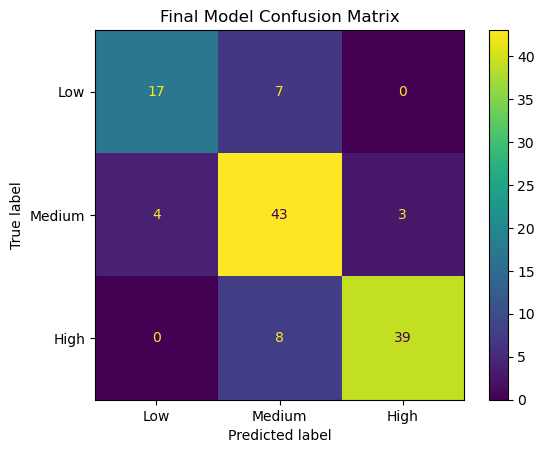

In [38]:
# Create the updated confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Low", "Medium", "High"]
)

plt.title("Final Model Confusion Matrix")
plt.show()

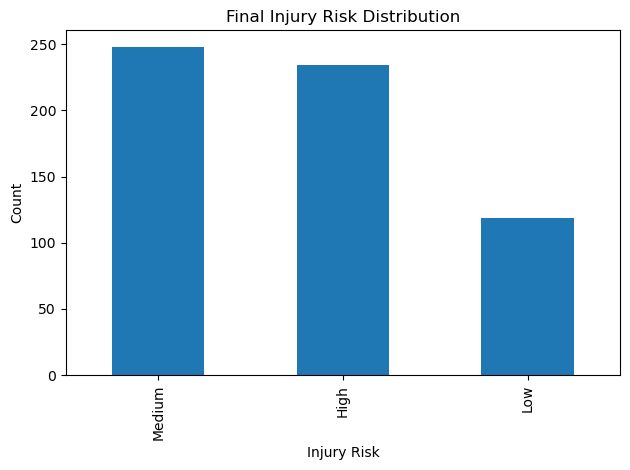

In [39]:
# Create the final risk distribution plot.
updated_gym_data["Injury_Risk"].value_counts().plot(kind="bar")

plt.title("Final Injury Risk Distribution")
plt.xlabel("Injury Risk")
plt.ylabel("Count")
plt.tight_layout()
plt.show()